### fine_tuning

In [1]:
import os
import random

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import torch
import torch.nn as nn

from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm


# ============================================================
# Global configuration
# ============================================================
RANDOM_SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SOURCE_DATA_PATH = "data/alldata_features.csv"
TARGET_DATA_PATH = "data/5metal_data_features.csv"

PRETRAINED_MODEL_PATH = "model/mlp_schemeD_pretrained.pth"
FINETUNED_MODEL_PATH = (
    "model/mlp_schemeD_final_finetuned.pth"
)
SCALER_PATH = "model/scaler_schemeD_pretrained.pkl"

RESULT_DIR = "feature_importance_results"
PRETRAIN_DIR = os.path.join(RESULT_DIR, "pretrained")
FINETUNE_DIR = os.path.join(RESULT_DIR, "finetuned")
COMPARISON_DIR = os.path.join(RESULT_DIR, "comparison")
CORRELATION_DIR = os.path.join(RESULT_DIR, "correlation")

for directory in [
    RESULT_DIR,
    PRETRAIN_DIR,
    FINETUNE_DIR,
    COMPARISON_DIR,
    CORRELATION_DIR,
]:
    os.makedirs(directory, exist_ok=True)


# ============================================================
# Plotting configuration
# ============================================================
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.size"] = 11
mpl.rcParams["axes.linewidth"] = 1.2


def set_random_seed(seed=RANDOM_SEED):
    """Set random seeds for reproducible analysis."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_random_seed()

print("Device:", DEVICE)

Device: cpu


In [2]:
# ============================================================
# MLP model
# ============================================================
class MLPRegressor(nn.Module):
    """Multilayer perceptron used for pretraining and fine-tuning."""

    def __init__(
        self,
        input_dim,
        hidden_dims=None,
        dropout=0.1,
    ):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = [256, 128, 64]

        feature_layers = []
        layer_dims = [input_dim] + hidden_dims

        for index in range(len(hidden_dims)):
            feature_layers.extend(
                [
                    nn.Linear(
                        layer_dims[index],
                        layer_dims[index + 1],
                    ),
                    nn.BatchNorm1d(
                        layer_dims[index + 1]
                    ),
                    nn.ReLU(),
                    nn.Dropout(dropout),
                ]
            )

        self.feature_extractor = nn.Sequential(
            *feature_layers
        )
        self.regressor = nn.Linear(
            hidden_dims[-1],
            1,
        )

    def forward(self, inputs):
        features = self.feature_extractor(inputs)
        return self.regressor(features)


# ============================================================
# Prediction and evaluation functions
# ============================================================
def predict_numpy(
    model,
    features,
    batch_size=256,
):
    """Generate predictions from a PyTorch model."""
    model.eval()
    predictions = []

    with torch.no_grad():
        for start_index in range(
            0,
            len(features),
            batch_size,
        ):
            batch = features[
                start_index:start_index + batch_size
            ]

            batch_tensor = torch.tensor(
                batch,
                dtype=torch.float32,
                device=DEVICE,
            )

            batch_predictions = (
                model(batch_tensor)
                .cpu()
                .numpy()
                .ravel()
            )

            predictions.extend(batch_predictions)

    return np.asarray(predictions)


def calculate_metrics(
    actual_values,
    predicted_values,
):
    """Calculate R2, MAE, and RMSE."""
    return {
        "R2": r2_score(
            actual_values,
            predicted_values,
        ),
        "MAE": mean_absolute_error(
            actual_values,
            predicted_values,
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                actual_values,
                predicted_values,
            )
        ),
    }


def print_metrics(title, metrics):
    """Print regression metrics."""
    print(f"\n{title}")

    for metric_name, metric_value in metrics.items():
        print(f"{metric_name}: {metric_value:.6f}")


def load_model(
    model_path,
    input_dim,
    dropout,
):
    """Load an MLP checkpoint."""
    model = MLPRegressor(
        input_dim=input_dim,
        hidden_dims=[256, 128, 64],
        dropout=dropout,
    ).to(DEVICE)

    state_dict = torch.load(
        model_path,
        map_location=DEVICE,
    )

    model.load_state_dict(state_dict)
    model.eval()

    return model

In [3]:
# ============================================================
# Load source-domain data
# ============================================================
source_df = pd.read_csv(SOURCE_DATA_PATH)

source_target = source_df[
    "overpotential"
].to_numpy()

source_feature_df = source_df.drop(
    columns=[
        "compound",
        "overpotential",
        "composition_key",
    ]
)

source_feature_names = (
    source_feature_df.columns.tolist()
)

source_features = (
    source_feature_df.to_numpy()
)


# ============================================================
# Reproduce the source-domain split
# ============================================================
(
    source_train_raw,
    source_validation_raw,
    source_train_target,
    source_validation_target,
) = train_test_split(
    source_features,
    source_target,
    test_size=0.2,
    random_state=42,
)


# ============================================================
# Load target-domain data
# ============================================================
target_df = pd.read_csv(TARGET_DATA_PATH)

target_values = target_df[
    "overpotential"
].to_numpy()

target_feature_df = target_df.drop(
    columns=[
        "compound",
        "overpotential",
        "composition_key",
    ]
)

target_feature_names = (
    target_feature_df.columns.tolist()
)

target_features = (
    target_feature_df.to_numpy()
)


# ============================================================
# Verify that both domains use identical input features
# ============================================================
if source_feature_names != target_feature_names:
    raise ValueError(
        "The source and target feature columns do not match."
    )

feature_names = source_feature_names


# ============================================================
# Reproduce the target-domain train/test split
# ============================================================
target_bins = pd.qcut(
    target_values,
    q=5,
    labels=False,
    duplicates="drop",
)

(
    target_trainval_raw,
    target_test_raw,
    target_trainval_values,
    target_test_values,
    target_trainval_bins,
    _,
) = train_test_split(
    target_features,
    target_values,
    target_bins,
    test_size=0.7,
    random_state=2027,
    stratify=target_bins,
)


# ============================================================
# Reproduce the internal split used during fine-tuning
# ============================================================
(
    target_train_raw,
    target_validation_raw,
    target_train_values,
    target_validation_values,
) = train_test_split(
    target_trainval_raw,
    target_trainval_values,
    test_size=0.2,
    random_state=42,
    stratify=target_trainval_bins,
)


# ============================================================
# Apply the source-domain scaler
# ============================================================
scaler = joblib.load(SCALER_PATH)

source_train_scaled = scaler.transform(
    source_train_raw
)

source_validation_scaled = scaler.transform(
    source_validation_raw
)

target_train_scaled = scaler.transform(
    target_train_raw
)

target_validation_scaled = scaler.transform(
    target_validation_raw
)

target_trainval_scaled = scaler.transform(
    target_trainval_raw
)

target_test_scaled = scaler.transform(
    target_test_raw
)


# ============================================================
# Display dataset information
# ============================================================
print(
    "Source training set:",
    source_train_scaled.shape,
)

print(
    "Source validation set:",
    source_validation_scaled.shape,
)

print(
    "Target training set:",
    target_train_scaled.shape,
)

print(
    "Target validation set:",
    target_validation_scaled.shape,
)

print(
    "Target train/validation set:",
    target_trainval_scaled.shape,
)

print(
    "Target independent test set:",
    target_test_scaled.shape,
)

print(
    "Number of input features:",
    len(feature_names),
)

Source training set: (676, 25)
Source validation set: (170, 25)
Target training set: (58, 25)
Target validation set: (15, 25)
Target train/validation set: (73, 25)
Target independent test set: (173, 25)
Number of input features: 25


In [4]:
# ============================================================
# Load the pretrained model
# ============================================================
pretrained_model = load_model(
    model_path=PRETRAINED_MODEL_PATH,
    input_dim=source_train_scaled.shape[1],
    dropout=0.1,
)


# ============================================================
# Load the fine-tuned model
# ============================================================
finetuned_model = load_model(
    model_path=FINETUNED_MODEL_PATH,
    input_dim=target_test_scaled.shape[1],
    dropout=0.02,
)


# ============================================================
# Evaluate the pretrained model
# ============================================================
pretrained_validation_predictions = predict_numpy(
    pretrained_model,
    source_validation_scaled,
)

pretrained_metrics = calculate_metrics(
    source_validation_target,
    pretrained_validation_predictions,
)

print_metrics(
    "Pretrained model on source validation set",
    pretrained_metrics,
)


# ============================================================
# Evaluate the fine-tuned model
# ============================================================
finetuned_test_predictions = predict_numpy(
    finetuned_model,
    target_test_scaled,
)

finetuned_metrics = calculate_metrics(
    target_test_values,
    finetuned_test_predictions,
)

print_metrics(
    "Fine-tuned model on independent target test set",
    finetuned_metrics,
)


Pretrained model on source validation set
R2: 0.816220
MAE: 0.111266
RMSE: 0.168754

Fine-tuned model on independent target test set
R2: 0.816281
MAE: 0.107576
RMSE: 0.134842


In [5]:
# ============================================================
# Permutation importance
# ============================================================
def calculate_permutation_importance(
    model,
    features,
    actual_values,
    feature_names,
    metric="R2",
    n_repeats=30,
    random_state=42,
    batch_size=256,
):
    """
    Calculate permutation importance.

    R2 importance is defined as the decrease in R2 after
    permutation. MAE and RMSE importance are defined as the
    increase in error after permutation.
    """
    random_generator = np.random.RandomState(
        random_state
    )

    baseline_predictions = predict_numpy(
        model,
        features,
        batch_size=batch_size,
    )

    baseline_metrics = calculate_metrics(
        actual_values,
        baseline_predictions,
    )

    baseline_score = baseline_metrics[metric]
    importance_records = []

    iterator = tqdm(
        enumerate(feature_names),
        total=len(feature_names),
        desc=f"Permutation importance ({metric})",
    )

    for feature_index, feature_name in iterator:
        repeated_importance = []

        for _ in range(n_repeats):
            permuted_features = features.copy()

            permuted_column = permuted_features[
                :, feature_index
            ].copy()

            random_generator.shuffle(
                permuted_column
            )

            permuted_features[
                :, feature_index
            ] = permuted_column

            permuted_predictions = predict_numpy(
                model,
                permuted_features,
                batch_size=batch_size,
            )

            permuted_metrics = calculate_metrics(
                actual_values,
                permuted_predictions,
            )

            permuted_score = permuted_metrics[metric]

            if metric == "R2":
                importance_value = (
                    baseline_score - permuted_score
                )
            else:
                importance_value = (
                    permuted_score - baseline_score
                )

            repeated_importance.append(
                importance_value
            )

        importance_records.append(
            {
                "feature": feature_name,
                "importance_mean": np.mean(
                    repeated_importance
                ),
                "importance_std": np.std(
                    repeated_importance
                ),
            }
        )

    importance_df = pd.DataFrame(
        importance_records
    )

    importance_df = importance_df.sort_values(
        "importance_mean",
        ascending=False,
    ).reset_index(drop=True)

    importance_df.insert(
        0,
        "rank",
        np.arange(1, len(importance_df) + 1),
    )

    return importance_df

In [6]:
# ============================================================
# Pretrained model: source validation set
# ============================================================
pretrained_importance_r2 = (
    calculate_permutation_importance(
        model=pretrained_model,
        features=source_validation_scaled,
        actual_values=source_validation_target,
        feature_names=feature_names,
        metric="R2",
        n_repeats=30,
        random_state=42,
    )
)

pretrained_importance_mae = (
    calculate_permutation_importance(
        model=pretrained_model,
        features=source_validation_scaled,
        actual_values=source_validation_target,
        feature_names=feature_names,
        metric="MAE",
        n_repeats=30,
        random_state=42,
    )
)

pretrained_importance_rmse = (
    calculate_permutation_importance(
        model=pretrained_model,
        features=source_validation_scaled,
        actual_values=source_validation_target,
        feature_names=feature_names,
        metric="RMSE",
        n_repeats=30,
        random_state=42,
    )
)


# ============================================================
# Fine-tuned model: independent target test set
# ============================================================
finetuned_importance_r2 = (
    calculate_permutation_importance(
        model=finetuned_model,
        features=target_test_scaled,
        actual_values=target_test_values,
        feature_names=feature_names,
        metric="R2",
        n_repeats=30,
        random_state=42,
    )
)

finetuned_importance_mae = (
    calculate_permutation_importance(
        model=finetuned_model,
        features=target_test_scaled,
        actual_values=target_test_values,
        feature_names=feature_names,
        metric="MAE",
        n_repeats=30,
        random_state=42,
    )
)

finetuned_importance_rmse = (
    calculate_permutation_importance(
        model=finetuned_model,
        features=target_test_scaled,
        actual_values=target_test_values,
        feature_names=feature_names,
        metric="RMSE",
        n_repeats=30,
        random_state=42,
    )
)


# ============================================================
# Save permutation importance results
# ============================================================
pretrained_importance_r2.to_csv(
    os.path.join(
        PRETRAIN_DIR,
        "permutation_importance_R2.csv",
    ),
    index=False,
)

pretrained_importance_mae.to_csv(
    os.path.join(
        PRETRAIN_DIR,
        "permutation_importance_MAE.csv",
    ),
    index=False,
)

pretrained_importance_rmse.to_csv(
    os.path.join(
        PRETRAIN_DIR,
        "permutation_importance_RMSE.csv",
    ),
    index=False,
)

finetuned_importance_r2.to_csv(
    os.path.join(
        FINETUNE_DIR,
        "permutation_importance_R2.csv",
    ),
    index=False,
)

finetuned_importance_mae.to_csv(
    os.path.join(
        FINETUNE_DIR,
        "permutation_importance_MAE.csv",
    ),
    index=False,
)

finetuned_importance_rmse.to_csv(
    os.path.join(
        FINETUNE_DIR,
        "permutation_importance_RMSE.csv",
    ),
    index=False,
)

print("\nPretrained model importance:")
display(pretrained_importance_r2)

print("\nFine-tuned model importance:")
display(finetuned_importance_r2)

Permutation importance (R2):   0%|          | 0/25 [00:00<?, ?it/s]

Permutation importance (MAE):   0%|          | 0/25 [00:00<?, ?it/s]

Permutation importance (RMSE):   0%|          | 0/25 [00:00<?, ?it/s]

Permutation importance (R2):   0%|          | 0/25 [00:00<?, ?it/s]

Permutation importance (MAE):   0%|          | 0/25 [00:00<?, ?it/s]

Permutation importance (RMSE):   0%|          | 0/25 [00:00<?, ?it/s]


Pretrained model importance:


,rank,feature,importance_mean,importance_std
0,1,CurrentDensity,0.722150,0.073761
1,2,M_AR,0.155199,0.024627
2,3,C_EN,0.130785,0.028732
3,4,s_mix_metal,0.097998,0.021035
4,5,M_EN_mismatch,0.091983,0.018555
5,6,M_EN,0.088168,0.013374
6,7,N_metal,0.083767,0.014499
7,8,M_AN,0.058946,0.014610
8,9,M_Nv,0.055366,0.010240
9,10,anion_to_metal_ratio,0.045059,0.019271



Fine-tuned model importance:


,rank,feature,importance_mean,importance_std
0,1,CurrentDensity,0.955533,0.072166
1,2,C_EN,0.439553,0.052368
2,3,M_AR_mismatch,0.289248,0.029797
3,4,M_EN_mismatch,0.184702,0.024975
4,5,M_EN,0.167436,0.024221
5,6,M_AN_mismatch,0.161240,0.027540
6,7,M_Nv_mismatch,0.141978,0.025236
7,8,M_AR,0.125163,0.019759
8,9,M_FIE_mismatch,0.124781,0.026155
9,10,M_EA_mismatch,0.090721,0.021440


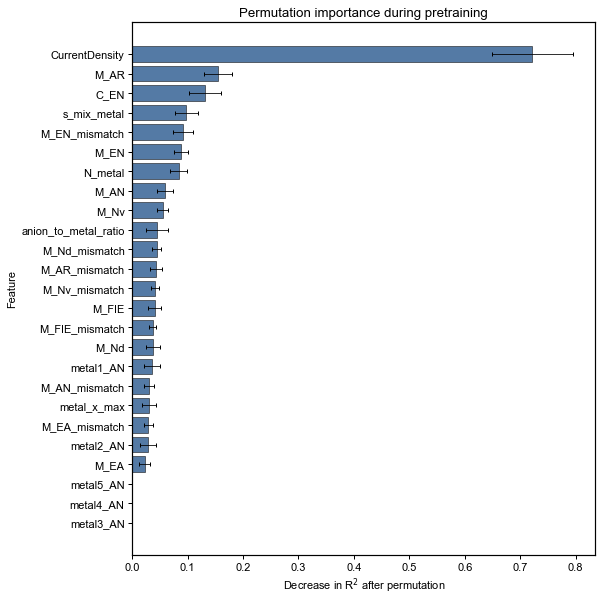

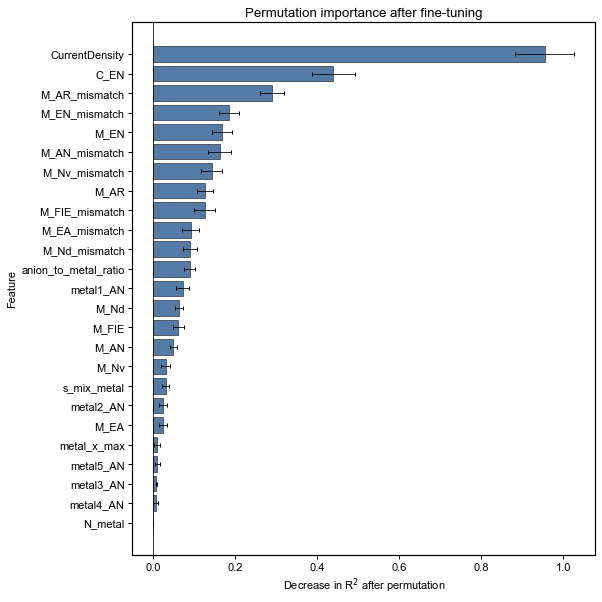

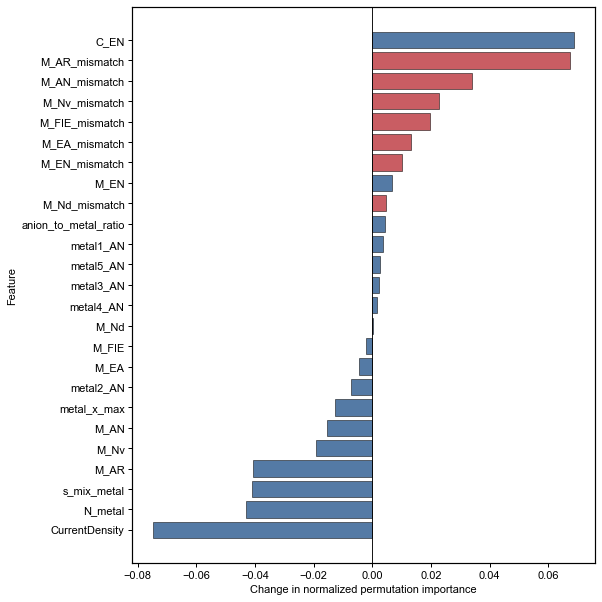

In [7]:
# ============================================================
# Plot permutation importance for an individual model
# ============================================================
def plot_permutation_importance(
    importance_df,
    title,
    output_path,
):
    plot_df = importance_df.iloc[::-1]

    figure_height = max(
        7,
        len(plot_df) * 0.34,
    )

    fig, axis = plt.subplots(
        figsize=(8.5, figure_height)
    )

    axis.barh(
        plot_df["feature"],
        plot_df["importance_mean"],
        xerr=plot_df["importance_std"],
        color="#547AA5",
        edgecolor="black",
        linewidth=0.5,
        error_kw={
            "elinewidth": 0.8,
            "capsize": 2,
        },
    )

    axis.axvline(
        0,
        color="black",
        linewidth=0.8,
    )

    axis.set_xlabel(
        "Decrease in R$^2$ after permutation"
    )

    axis.set_ylabel("Feature")
    axis.set_title(title)

    axis.tick_params(
        direction="out",
        length=4,
        width=1,
    )

    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=600,
        bbox_inches="tight",
    )

    plt.show()


plot_permutation_importance(
    pretrained_importance_r2,
    "Permutation importance during pretraining",
    os.path.join(
        PRETRAIN_DIR,
        "permutation_importance_R2.png",
    ),
)

plot_permutation_importance(
    finetuned_importance_r2,
    "Permutation importance after fine-tuning",
    os.path.join(
        FINETUNE_DIR,
        "permutation_importance_R2.png",
    ),
)


# ============================================================
# Normalize permutation importance
# ============================================================
def normalize_positive_importance(
    importance_df,
    output_column,
):
    normalized_df = importance_df[
        ["feature", "importance_mean"]
    ].copy()

    positive_values = normalized_df[
        "importance_mean"
    ].clip(lower=0)

    positive_sum = positive_values.sum()

    if positive_sum == 0:
        normalized_df[output_column] = 0.0
    else:
        normalized_df[output_column] = (
            positive_values / positive_sum
        )

    return normalized_df[
        ["feature", output_column]
    ]


pretrained_normalized = (
    normalize_positive_importance(
        pretrained_importance_r2,
        "pretrained_normalized",
    )
)

finetuned_normalized = (
    normalize_positive_importance(
        finetuned_importance_r2,
        "finetuned_normalized",
    )
)


# ============================================================
# Calculate the change after fine-tuning
# ============================================================
importance_change = pretrained_normalized.merge(
    finetuned_normalized,
    on="feature",
    how="inner",
)

importance_change["normalized_change"] = (
    importance_change["finetuned_normalized"]
    - importance_change["pretrained_normalized"]
)

importance_change = importance_change.sort_values(
    "normalized_change",
    ascending=True,
).reset_index(drop=True)

importance_change.to_csv(
    os.path.join(
        COMPARISON_DIR,
        "normalized_importance_change.csv",
    ),
    index=False,
)


# ============================================================
# Highlight mismatch descriptors
# ============================================================
mismatch_features = [
    "M_AN_mismatch",
    "M_AR_mismatch",
    "M_FIE_mismatch",
    "M_EA_mismatch",
    "M_EN_mismatch",
    "M_Nd_mismatch",
    "M_Nv_mismatch",
]

bar_colors = [
    "#C95D63"
    if feature in mismatch_features
    else "#547AA5"
    for feature in importance_change["feature"]
]


# ============================================================
# Plot normalized importance changes
# ============================================================
fig, axis = plt.subplots(
    figsize=(
        8.5,
        max(7, len(importance_change) * 0.34),
    )
)

axis.barh(
    importance_change["feature"],
    importance_change["normalized_change"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.5,
)

axis.axvline(
    0,
    color="black",
    linewidth=0.9,
)

axis.set_xlabel(
    "Change in normalized permutation importance"
)

axis.set_ylabel("Feature")

axis.tick_params(
    direction="out",
    length=4,
    width=1,
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        COMPARISON_DIR,
        "normalized_importance_change.png",
    ),
    dpi=600,
    bbox_inches="tight",
)

plt.savefig(
    os.path.join(
        COMPARISON_DIR,
        "normalized_importance_change.svg",
    ),
    bbox_inches="tight",
)

plt.show()

pretrained background shape: (50, 25)
pretrained explained data shape: (170, 25)


  0%|          | 0/170 [00:00<?, ?it/s]

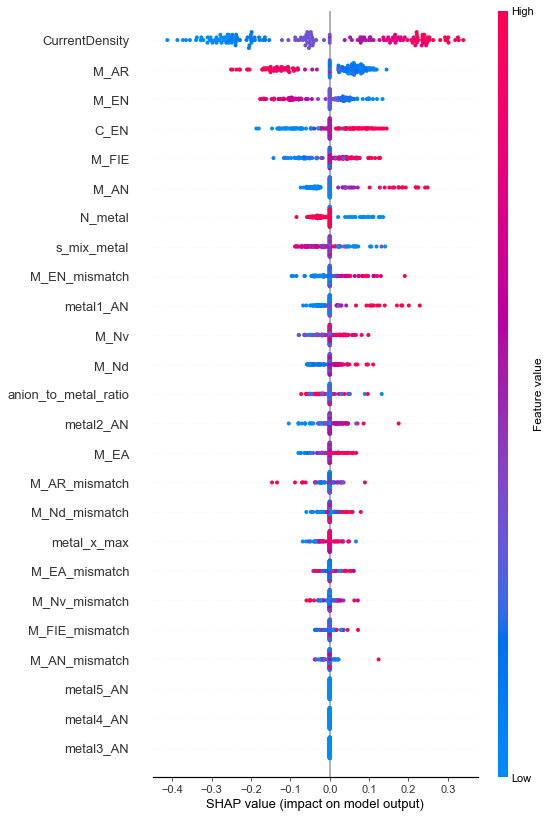

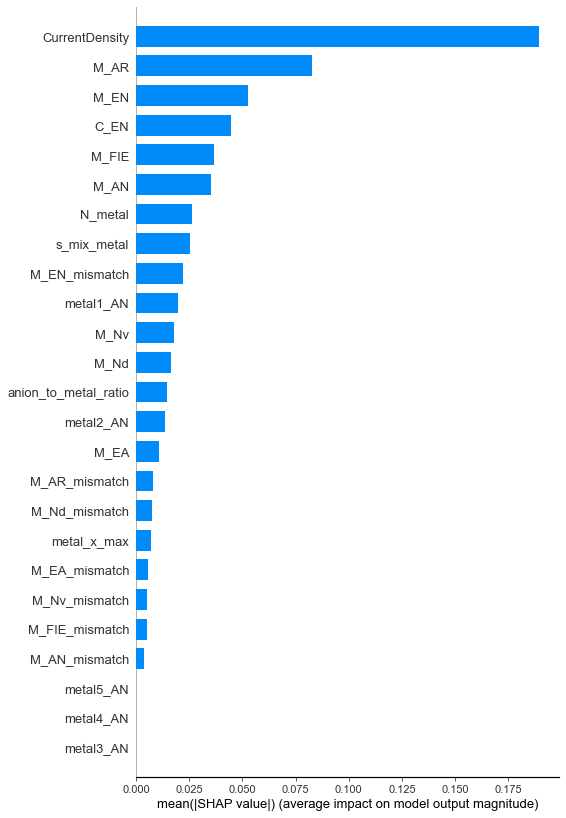

finetuned background shape: (50, 25)
finetuned explained data shape: (173, 25)


  0%|          | 0/173 [00:00<?, ?it/s]

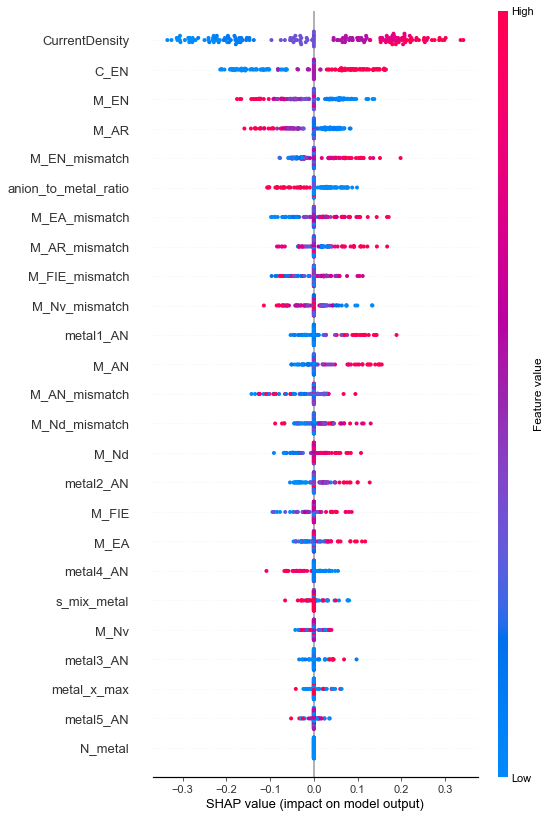

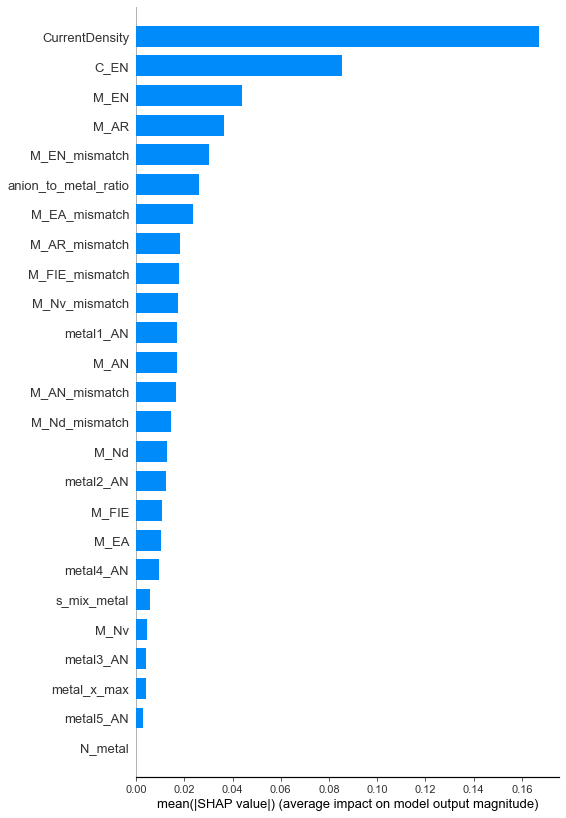

In [8]:
# ============================================================
# SHAP analysis function
# ============================================================
def run_shap_analysis(
    model,
    background_features,
    explained_features,
    feature_names,
    output_directory,
    file_label,
    background_size=50,
    nsamples=100,
):
    """Run Kernel SHAP and save global feature importance."""
    np.random.seed(RANDOM_SEED)

    selected_background_size = min(
        background_size,
        len(background_features),
    )

    background_indices = np.random.choice(
        len(background_features),
        size=selected_background_size,
        replace=False,
    )

    selected_background = background_features[
        background_indices
    ]

    def prediction_function(input_features):
        input_features = np.asarray(
            input_features,
            dtype=np.float32,
        )

        return predict_numpy(
            model,
            input_features,
            batch_size=256,
        )

    print(
        f"{file_label} background shape:",
        selected_background.shape,
    )

    print(
        f"{file_label} explained data shape:",
        explained_features.shape,
    )

    explainer = shap.KernelExplainer(
        prediction_function,
        selected_background,
    )

    shap_values = explainer.shap_values(
        explained_features,
        nsamples=nsamples,
    )

    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    shap_values = np.asarray(shap_values)

    if shap_values.ndim == 3:
        shap_values = np.squeeze(shap_values)

    shap_value_df = pd.DataFrame(
        shap_values,
        columns=feature_names,
    )

    shap_value_df.to_csv(
        os.path.join(
            output_directory,
            f"shap_values_{file_label}.csv",
        ),
        index=False,
    )

    shap_importance_df = pd.DataFrame(
        {
            "feature": feature_names,
            "mean_absolute_shap": np.mean(
                np.abs(shap_values),
                axis=0,
            ),
        }
    )

    shap_importance_df = (
        shap_importance_df
        .sort_values(
            "mean_absolute_shap",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    shap_importance_df.insert(
        0,
        "rank",
        np.arange(
            1,
            len(shap_importance_df) + 1,
        ),
    )

    shap_importance_df.to_csv(
        os.path.join(
            output_directory,
            f"shap_importance_{file_label}.csv",
        ),
        index=False,
    )

    plt.figure(
        figsize=(
            9,
            max(7, len(feature_names) * 0.34),
        )
    )

    shap.summary_plot(
        shap_values,
        explained_features,
        feature_names=feature_names,
        max_display=len(feature_names),
        show=False,
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            output_directory,
            f"shap_summary_{file_label}.png",
        ),
        dpi=600,
        bbox_inches="tight",
    )

    plt.show()

    plt.figure(
        figsize=(
            9,
            max(7, len(feature_names) * 0.34),
        )
    )

    shap.summary_plot(
        shap_values,
        explained_features,
        feature_names=feature_names,
        plot_type="bar",
        max_display=len(feature_names),
        show=False,
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            output_directory,
            f"shap_bar_{file_label}.png",
        ),
        dpi=600,
        bbox_inches="tight",
    )

    plt.show()

    return shap_values, shap_importance_df


# ============================================================
# SHAP analysis during pretraining
# ============================================================
(
    pretrained_shap_values,
    pretrained_shap_importance,
) = run_shap_analysis(
    model=pretrained_model,
    background_features=source_train_scaled,
    explained_features=source_validation_scaled,
    feature_names=feature_names,
    output_directory=PRETRAIN_DIR,
    file_label="pretrained",
    background_size=50,
    nsamples=100,
)


# ============================================================
# SHAP analysis after fine-tuning
# ============================================================
(
    finetuned_shap_values,
    finetuned_shap_importance,
) = run_shap_analysis(
    model=finetuned_model,
    background_features=target_train_scaled,
    explained_features=target_test_scaled,
    feature_names=feature_names,
    output_directory=FINETUNE_DIR,
    file_label="finetuned",
    background_size=50,
    nsamples=100,
)

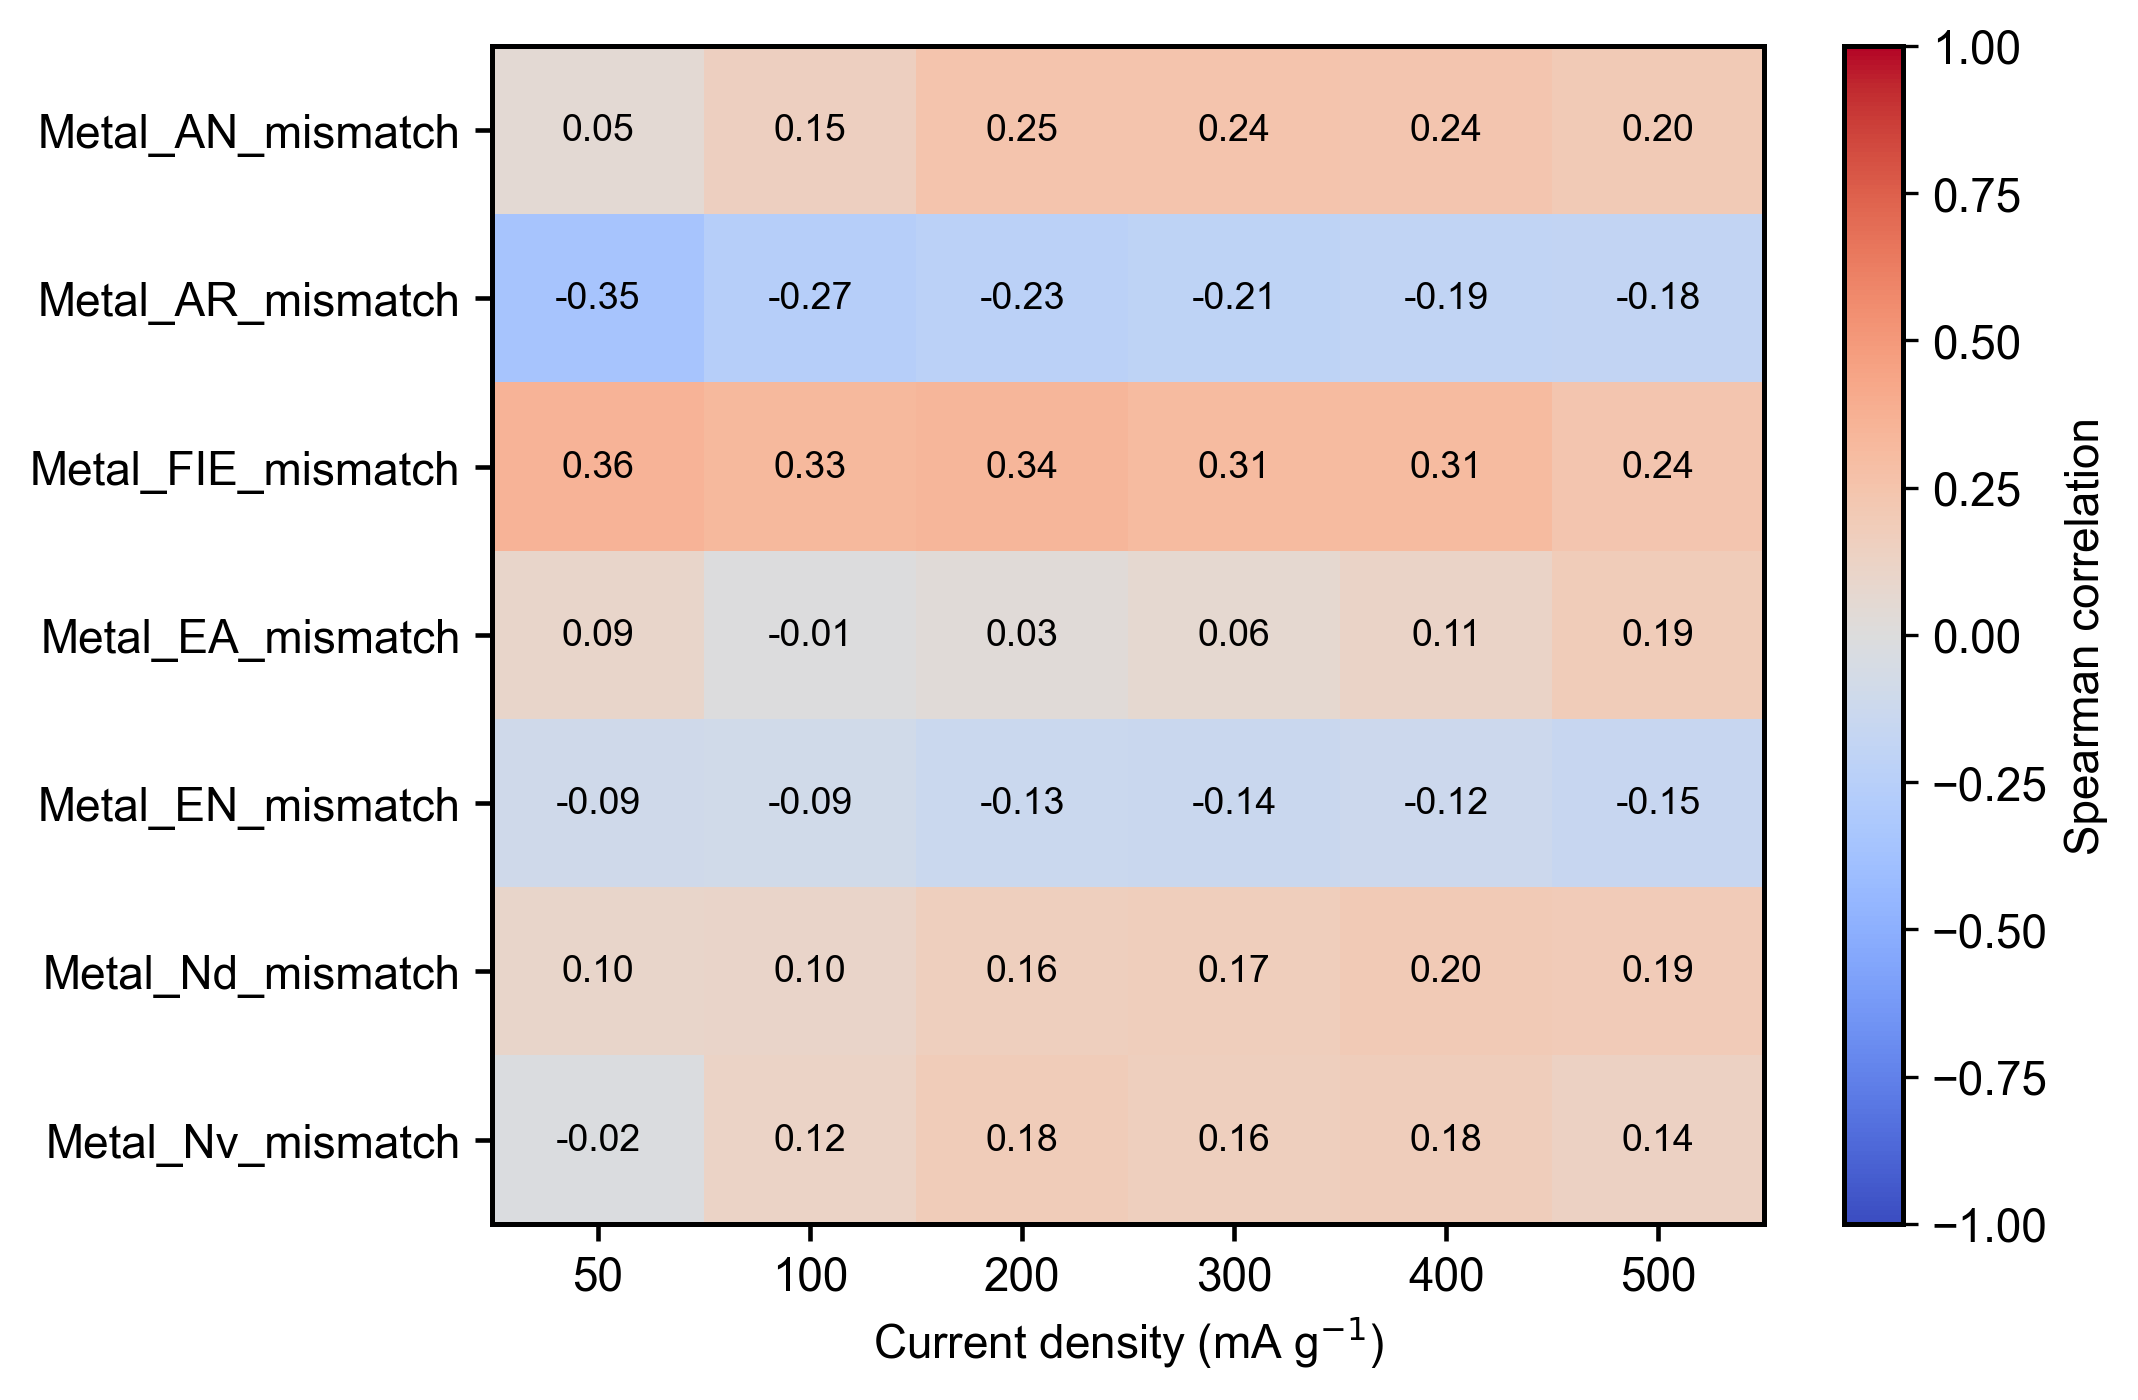

In [9]:
# ============================================================
# Verify mismatch descriptors
# ============================================================
available_mismatch_features = [
    feature
    for feature in mismatch_features
    if feature in target_df.columns
]

missing_mismatch_features = [
    feature
    for feature in mismatch_features
    if feature not in target_df.columns
]

if missing_mismatch_features:
    print(
        "Missing mismatch descriptors:",
        missing_mismatch_features,
    )

if "CurrentDensity" not in target_df.columns:
    raise KeyError(
        "CurrentDensity is missing from the target dataset."
    )


# ============================================================
# Calculate Spearman correlations at each current density
# ============================================================
correlation_records = []

current_densities = sorted(
    target_df["CurrentDensity"]
    .dropna()
    .unique()
)

for current_density in current_densities:
    current_subset = target_df.loc[
        target_df["CurrentDensity"]
        == current_density
    ]

    for feature in available_mismatch_features:
        valid_data = current_subset[
            [feature, "overpotential"]
        ].dropna()

        if (
            len(valid_data) < 3
            or valid_data[feature].nunique() < 2
            or valid_data["overpotential"].nunique() < 2
        ):
            correlation_value = np.nan
            p_value = np.nan
        else:
            correlation_value, p_value = spearmanr(
                valid_data[feature],
                valid_data["overpotential"],
            )

        correlation_records.append(
            {
                "CurrentDensity": current_density,
                "feature": feature,
                "spearman_correlation": (
                    correlation_value
                ),
                "p_value": p_value,
                "n_samples": len(valid_data),
            }
        )


correlation_df = pd.DataFrame(
    correlation_records
)

correlation_df.to_csv(
    os.path.join(
        CORRELATION_DIR,
        "mismatch_spearman_correlations.csv",
    ),
    index=False,
)


# ============================================================
# Construct the heatmap matrix
# ============================================================
heatmap_df = correlation_df.pivot(
    index="feature",
    columns="CurrentDensity",
    values="spearman_correlation",
)

heatmap_df = heatmap_df.reindex(
    available_mismatch_features
)


# ============================================================
# Labels used in the publication figure
# ============================================================
feature_label_map = {
    "M_AN_mismatch": "Metal_AN_mismatch",
    "M_AR_mismatch": "Metal_AR_mismatch",
    "M_FIE_mismatch": "Metal_FIE_mismatch",
    "M_EA_mismatch": "Metal_EA_mismatch",
    "M_EN_mismatch": "Metal_EN_mismatch",
    "M_Nd_mismatch": "Metal_Nd_mismatch",
    "M_Nv_mismatch": "Metal_Nv_mismatch",
}

heatmap_plot_df = heatmap_df.copy()

heatmap_plot_df.index = [
    feature_label_map.get(feature, feature)
    for feature in heatmap_plot_df.index
]


# ============================================================
# Plot the correlation heatmap
# ============================================================
fig, axis = plt.subplots(
    figsize=(7.2, 4.8),
    dpi=300,
)

heatmap_image = axis.imshow(
    heatmap_plot_df.values,
    aspect="auto",
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)

axis.set_xticks(
    np.arange(len(heatmap_plot_df.columns))
)

axis.set_xticklabels(
    [
        str(value)
        for value in heatmap_plot_df.columns
    ]
)

axis.set_yticks(
    np.arange(len(heatmap_plot_df.index))
)

axis.set_yticklabels(
    heatmap_plot_df.index
)

axis.set_xlabel(
    "Current density (mA g$^{-1}$)"
)

axis.tick_params(
    axis="both",
    direction="out",
    length=4,
    width=1.1,
)

colorbar = fig.colorbar(
    heatmap_image,
    ax=axis,
)

colorbar.set_label(
    "Spearman correlation"
)

for row_index in range(
    heatmap_plot_df.shape[0]
):
    for column_index in range(
        heatmap_plot_df.shape[1]
    ):
        correlation_value = heatmap_plot_df.iloc[
            row_index,
            column_index,
        ]

        if np.isnan(correlation_value):
            display_text = "NA"
            text_color = "black"
        else:
            display_text = f"{correlation_value:.2f}"
            text_color = (
                "white"
                if abs(correlation_value) > 0.55
                else "black"
            )

        axis.text(
            column_index,
            row_index,
            display_text,
            ha="center",
            va="center",
            fontsize=9,
            color=text_color,
        )

plt.tight_layout()

plt.savefig(
    os.path.join(
        CORRELATION_DIR,
        "mismatch_correlation_heatmap.png",
    ),
    dpi=600,
    bbox_inches="tight",
)

plt.savefig(
    os.path.join(
        CORRELATION_DIR,
        "mismatch_correlation_heatmap.svg",
    ),
    bbox_inches="tight",
)

plt.show()